# Trader Performance vs Market Sentiment Analysis

This notebook analyzes the relationship between Bitcoin market sentiment and trader performance using the prepared modeling dataset. The analysis evaluates trading performance, behavioral patterns, trader segments, and data-driven strategy recommendations.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
# Load Final Modeling Dataset

df = pd.read_csv("../data/processed/trader_sentiment_model.csv")

print(f"Dataset Shape: {df.shape}")

df.head()

Dataset Shape: (211224, 26)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value,Year,Quarter,Month,Month Name,Week,Day,Day Name
0,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.0722,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-05-01,Greed,63.0,2023,2,5,May,18,1,Monday
1,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0967,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-05-01,Greed,63.0,2023,2,5,May,18,1,Monday
2,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.0824,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,2023-03-28 10:40:00,2023-05-01,Greed,63.0,2023,2,5,May,18,1,Monday
3,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2231.0,3.8932,8685.73,BUY,2023-12-05 03:11:00,7.3187,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,2.171432,1.060000e+15,2023-11-14 22:13:20,2023-12-05,Extreme Greed,75.0,2023,4,12,December,49,5,Tuesday
4,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.2,0.4484,1000.02,BUY,2023-12-05 03:11:00,6.8703,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.250005,2.920000e+14,2023-11-14 22:13:20,2023-12-05,Extreme Greed,75.0,2023,4,12,December,49,5,Tuesday


## Performance Analysis

This section compares trader performance across different market sentiment conditions using key performance metrics, including profit and loss, trade outcomes, and trading activity.

In [3]:
# Performance Summary by Market Sentiment

performance_summary = (
    df.groupby("classification")
      .agg(
          Total_Trades=("Closed PnL", "count"),
          Total_PnL=("Closed PnL", "sum"),
          Average_PnL=("Closed PnL", "mean"),
          Median_PnL=("Closed PnL", "median"),
          Max_PnL=("Closed PnL", "max"),
          Min_PnL=("Closed PnL", "min")
      )
      .round(2)
      .sort_values("Total_PnL", ascending=False)
)

performance_summary

,Total_Trades,Total_PnL,Average_PnL,Median_PnL,Max_PnL,Min_PnL
classification,,,,,,
Fear,61837,3357155.44,54.29,0.0,135329.09,-35681.75
Extreme Greed,39992,2715171.31,67.89,0.0,44223.45,-10259.47
Greed,50309,2192601.27,43.58,0.0,74530.52,-117990.10
Neutral,37686,1292920.68,34.31,0.0,48504.10,-24500.00
Extreme Fear,21400,739110.25,34.54,0.0,115287.00,-31036.69


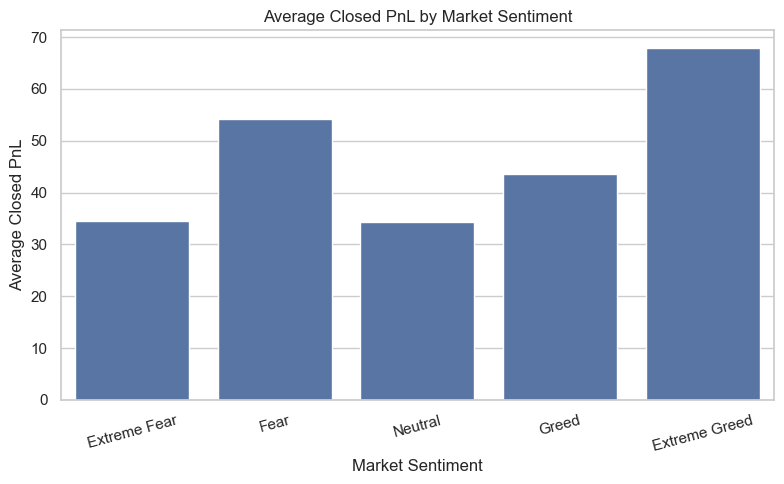

In [4]:
# Average Closed PnL by Market Sentiment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None,
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [5]:
# Win Rate by Market Sentiment

win_rate = (
    df.groupby("classification")["Closed PnL"]
      .apply(lambda x: (x > 0).mean() * 100)
      .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
      .round(2)
      .reset_index(name="Win Rate (%)")
)

win_rate

,classification,Win Rate (%)
0,Extreme Fear,37.06
1,Fear,42.08
2,Neutral,39.70
3,Greed,38.49
4,Extreme Greed,46.49


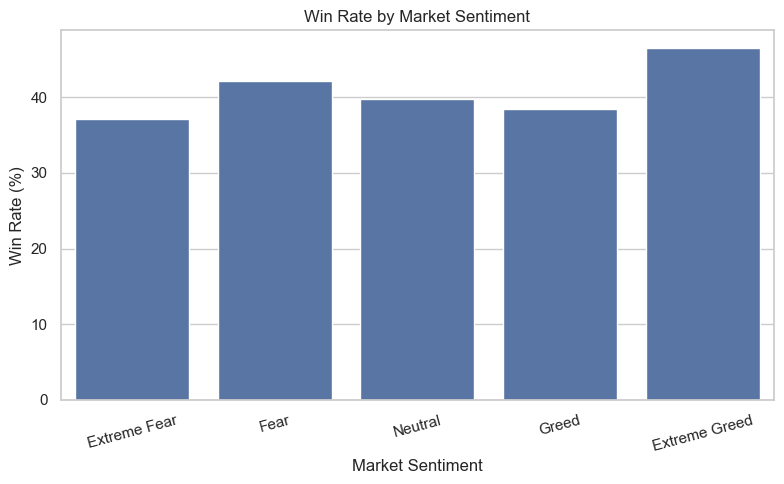

In [6]:
# Win Rate by Market Sentiment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=win_rate,
    x="classification",
    y="Win Rate (%)",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [7]:
# Drawdown Proxy by Market Sentiment (Average Loss per Losing Trade)

drawdown_proxy = (
    df[df["Closed PnL"] < 0]
    .groupby("classification")["Closed PnL"]
    .mean()
    .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
    .round(2)
    .reset_index(name="Average Loss")
)

drawdown_proxy

,classification,Average Loss
0,Extreme Fear,-257.10
1,Fear,-156.66
2,Neutral,-121.73
3,Greed,-181.97
4,Extreme Greed,-119.92


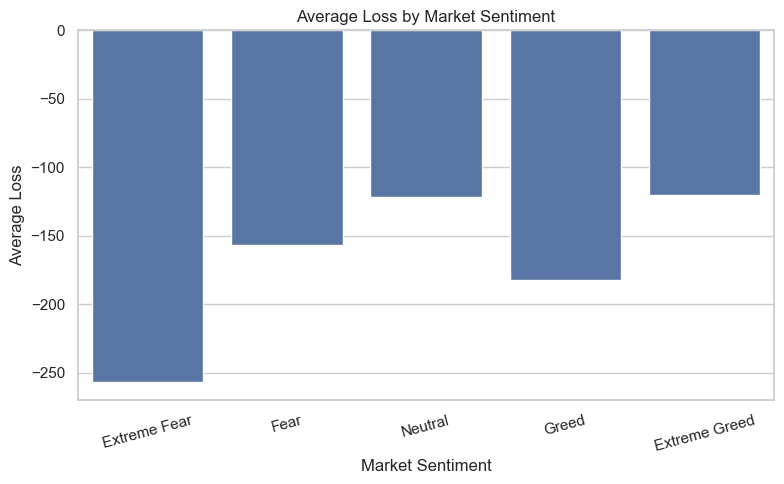

In [8]:
# Drawdown Proxy by Market Sentiment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=drawdown_proxy,
    x="classification",
    y="Average Loss",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)

plt.title("Average Loss by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Loss")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

## Trader Behavior Analysis

This section examines how trading behavior varies across market sentiment conditions by comparing trading activity, position sizes, leverage usage, and long versus short trading preferences.

In [9]:
# Trading Activity by Market Sentiment

trade_activity = (
    df.groupby("classification")
      .agg(
          Total_Trades=("Account", "count"),
          Unique_Traders=("Account", "nunique")
      )
      .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
      .reset_index()
)

trade_activity

,classification,Total_Trades,Unique_Traders
0,Extreme Fear,21400,32
1,Fear,61837,32
2,Neutral,37686,31
3,Greed,50309,31
4,Extreme Greed,39992,30


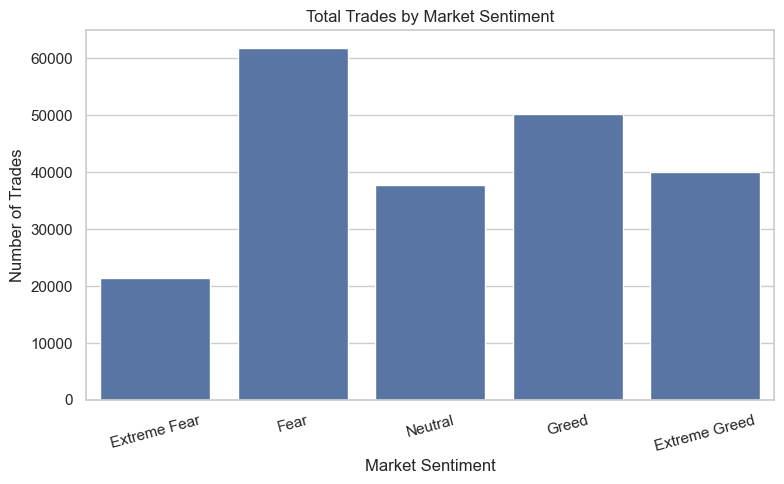

In [10]:
# Trading Activity by Market Sentiment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=trade_activity,
    x="classification",
    y="Total_Trades",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)

plt.title("Total Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [11]:
# Average Position Size by Market Sentiment

position_size = (
    df.groupby("classification")["Size USD"]
      .mean()
      .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
      .round(2)
      .reset_index(name="Average Position Size (USD)")
)

position_size

,classification,Average Position Size (USD)
0,Extreme Fear,5349.73
1,Fear,7816.11
2,Neutral,4782.73
3,Greed,5737.96
4,Extreme Greed,3112.25


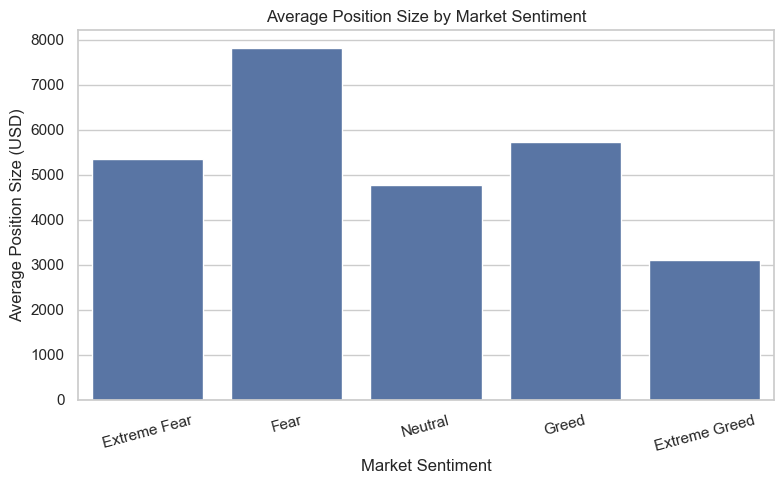

In [12]:
# Average Position Size by Market Sentiment

plt.figure(figsize=(8, 5))

sns.barplot(
    data=position_size,
    x="classification",
    y="Average Position Size (USD)",
    order=["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
)

plt.title("Average Position Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Position Size (USD)")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [13]:
# Long vs Short Trading Preference by Market Sentiment

long_short = (
    df.groupby(["classification", "Side"])
      .size()
      .unstack(fill_value=0)
      .reindex(["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"])
)

long_short

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Fear,30270,31567
Neutral,18969,18717
Greed,24582,25727
Extreme Greed,17940,22052


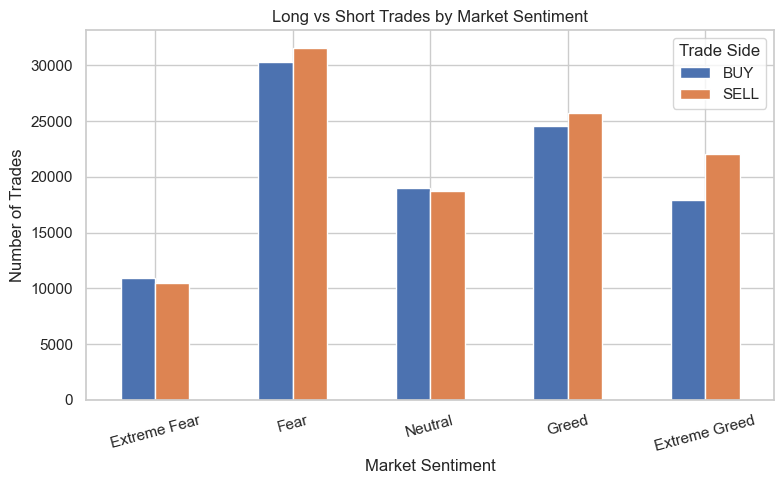

In [14]:
# Long vs Short Trading Preference by Market Sentiment

long_short.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=15)
plt.legend(title="Trade Side")

plt.tight_layout()
plt.show()

## Trader Segmentation

This section segments traders based on their trading activity and performance to identify distinct behavioral groups and compare their overall profitability.

In [15]:
# Segment 1: Frequent vs Infrequent Traders

trader_activity = (
    df.groupby("Account")
      .agg(
          Total_Trades=("Account", "count"),
          Total_PnL=("Closed PnL", "sum")
      )
)

median_trades = trader_activity["Total_Trades"].median()

trader_activity["Segment"] = np.where(
    trader_activity["Total_Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

activity_segment = (
    trader_activity.groupby("Segment")
    .agg(
        Traders=("Segment", "count"),
        Average_Trades=("Total_Trades", "mean"),
        Average_PnL=("Total_PnL", "mean")
    )
    .round(2)
)

activity_segment

,Traders,Average_Trades,Average_PnL
Segment,,,
Frequent,16,11684.81,496527.66
Infrequent,16,1516.69,147032.27


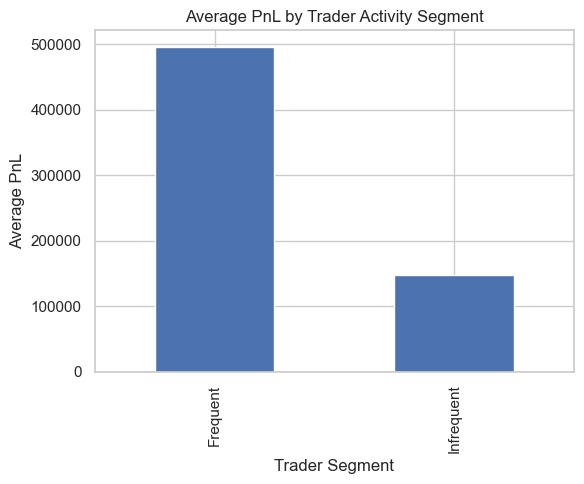

In [16]:
# Frequent vs Infrequent Traders

activity_segment.plot(
    kind="bar",
    y="Average_PnL",
    figsize=(6, 5),
    legend=False
)

plt.title("Average PnL by Trader Activity Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL")

plt.tight_layout()
plt.show()

In [17]:
# Segment 2: Consistent Winners vs Inconsistent Traders

trader_performance = (
    df.groupby("Account")
      .agg(
          Win_Rate=("Closed PnL", lambda x: (x > 0).mean() * 100),
          Total_PnL=("Closed PnL", "sum")
      )
)

median_win_rate = trader_performance["Win_Rate"].median()

trader_performance["Segment"] = np.where(
    trader_performance["Win_Rate"] >= median_win_rate,
    "Consistent Winners",
    "Inconsistent Traders"
)

performance_segment = (
    trader_performance.groupby("Segment")
    .agg(
        Traders=("Segment", "count"),
        Average_Win_Rate=("Win_Rate", "mean"),
        Average_PnL=("Total_PnL", "mean")
    )
    .round(2)
)

performance_segment

,Traders,Average_Win_Rate,Average_PnL
Segment,,,
Consistent Winners,16,48.22,296760.27
Inconsistent Traders,16,32.39,346799.67


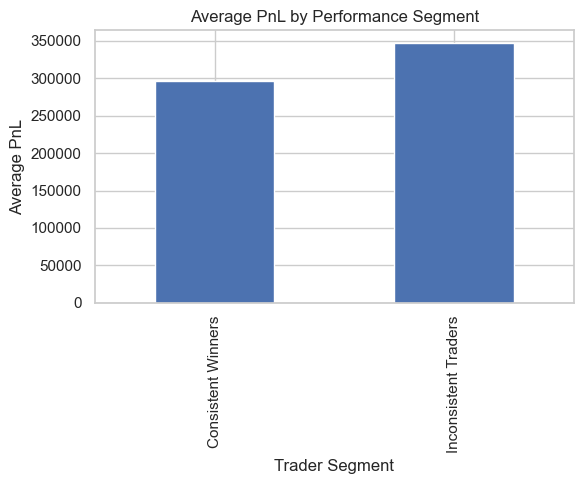

In [18]:
# Consistent Winners vs Inconsistent Traders

performance_segment.plot(
    kind="bar",
    y="Average_PnL",
    figsize=(6, 5),
    legend=False
)

plt.title("Average PnL by Performance Segment")
plt.xlabel("Trader Segment")
plt.ylabel("Average PnL")

plt.tight_layout()
plt.show()

## Key Insights

The analysis highlights several notable patterns in trader performance and behavior across different market sentiment conditions:

- Extreme Greed recorded the highest average profit per trade and the highest win rate, indicating stronger trading performance during highly optimistic market conditions.
- Fear periods experienced the highest trading activity and the largest average position sizes, suggesting traders were more active and committed larger capital during fearful markets.
- Frequent traders generated significantly higher average total profit than infrequent traders, indicating that higher trading activity was associated with greater overall profitability.

## Strategy Recommendations

Based on the observed relationship between market sentiment and trader performance, the following strategies are recommended:

- During Extreme Greed periods, traders may consider maintaining disciplined exposure, as these conditions demonstrated the highest average profitability and win rate.
- During Fear periods, traders should apply stricter risk management despite higher trading activity and larger position sizes to reduce the impact of potential losses.

## Conclusion

This analysis examined trader performance and trading behavior under different market sentiment conditions using historical Hyperliquid trading data. The results show that market sentiment is associated with differences in profitability, trading activity, position sizing, and trader performance. These findings provide practical insights that can support more informed trading decisions and risk management strategies.